In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# Learning rewards from text and judging reasoning steps

The earlier linear reward microscope started with known quality/length/format features. Here the model receives only token IDs: a tiny causal decoder must learn a representation and a scalar head from original authored labels. We then ask whether the scalar stays reliable when formatting changes, and whether a correct final answer says anything about the steps that preceded it.

The fixture is original **authored** text and supervision, not human feedback or AI judgments. Everything runs on CPU. No pretrained model, credential, installation or live service is needed. Predictions precede complete adjacent references; saved figures are fixed reference previews, not live controls.

[Chapter 10](../../book/chapters/10-preferences-and-reward-models.md) · [worked solutions](../../book/solutions/10-preferences-and-reward-models.md) · [experiment specification](../../experiments/specs/2026-10-04-text-reward.md)

In [2]:
from pathlib import Path
import sys, json
from copy import deepcopy
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/dongxi_llms').is_dir())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
from dongxi_llms.text_reward_lab import (
    RewardConfig, TinyTextReward, load_fixture, fixture_vocabulary, text_batch,
    process_batch, fit_text_model, evaluate_pairs, evaluate_traces, nuisance_pairs,
    load_frozen, last_valid_indices,
)
torch.set_num_threads(1)  # Explicit bounded CPU lesson setting.
plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})
fixture = load_fixture(ROOT / 'fixtures/text-reward/records.json')
vocab = fixture_vocabulary(fixture)
report = json.loads((ROOT / 'experiments/reports/2026-10-04-text-reward.json').read_text())
with torch.random.fork_rng():
    torch.manual_seed(1601)
    initial = TinyTextReward(RewardConfig(len(vocab.tokens)))
print('Vocabulary:', len(vocab.tokens), '| train-only text plus declared formatting alphabet')
print('Parameter count:', sum(p.numel() for p in initial.parameters()))
print('Unknown policy:', vocab.unknown_policy, '| no silent truncation')

Vocabulary: 40 | train-only text plus declared formatting alphabet
Parameter count: 8209
Unknown policy: unk | no silent truncation


## 1 A scalar head sees a contextual text representation

Predict: if the reward is evaluated at an EOS token, does only the EOS embedding learn? How can the earlier question and answer words affect that scalar?

The next figure is an architecture schematic, not a measurement. Its left map locates the scalar reward head in the ordinary decoder pipeline; its right map shows how both answer branches share parameters.

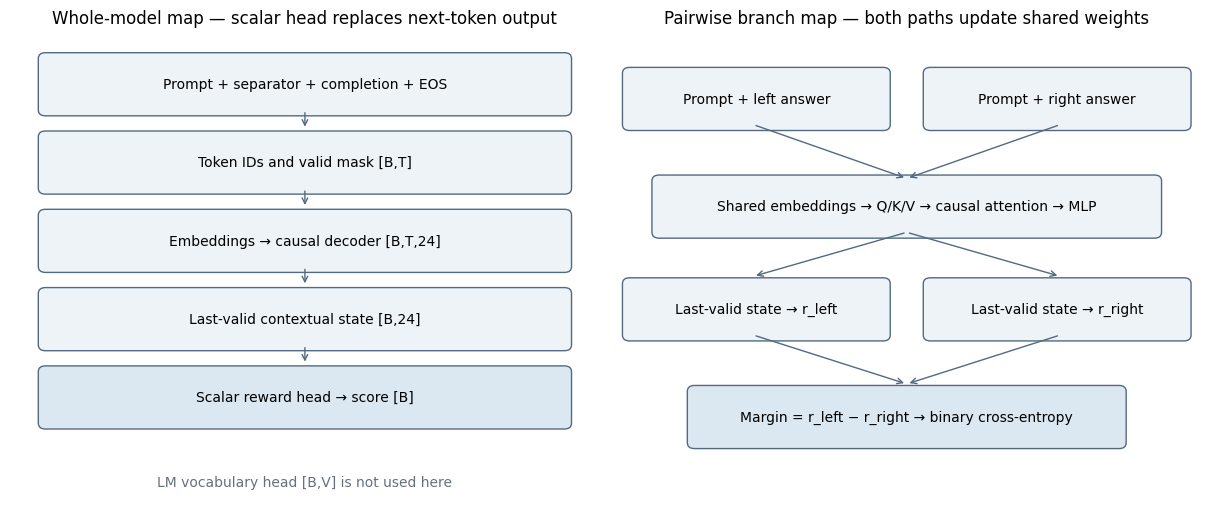

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), constrained_layout=True)
def box(ax, x, y, text, width=.88, height=.105, color='#eef3f7'):
    patch = FancyBboxPatch((x, y), width, height, boxstyle='round,pad=.012',
                          facecolor=color, edgecolor='#526a80')
    ax.add_patch(patch)
    ax.text(x + width / 2, y + height / 2, text, ha='center', va='center', fontsize=10)
for ax in axes:
    ax.set(xlim=(0, 1), ylim=(0, 1)); ax.axis('off')
labels = [('Prompt + separator + completion + EOS', .84), ('Token IDs and valid mask [B,T]', .68),
          ('Embeddings → causal decoder [B,T,24]', .52), ('Last-valid contextual state [B,24]', .36),
          ('Scalar reward head → score [B]', .20)]
for label, y in labels:
    box(axes[0], .06, y, label, color='#dbe8f2' if 'Scalar' in label else '#eef3f7')
    if y > .20:
        axes[0].annotate('', (.5, y - .04), (.5, y), arrowprops={'arrowstyle':'->','color':'#526a80'})
axes[0].text(.5, .07, 'LM vocabulary head [B,V] is not used here', ha='center', fontsize=10, color='#65717b')
axes[0].set_title('Whole-model map — scalar head replaces next-token output')
box(axes[1], .03, .81, 'Prompt + left answer', width=.43)
box(axes[1], .54, .81, 'Prompt + right answer', width=.43)
box(axes[1], .08, .59, 'Shared embeddings → Q/K/V → causal attention → MLP', width=.84)
for x in (.24, .76):
    axes[1].annotate('', (.5, .70), (x, .81), arrowprops={'arrowstyle':'->','color':'#526a80'})
box(axes[1], .03, .38, 'Last-valid state → r_left', width=.43)
box(axes[1], .54, .38, 'Last-valid state → r_right', width=.43)
for x in (.24, .76):
    axes[1].annotate('', (x, .50), (.5, .59), arrowprops={'arrowstyle':'->','color':'#526a80'})
box(axes[1], .14, .16, 'Margin = r_left − r_right → binary cross-entropy', width=.72, color='#dbe8f2')
for x in (.24, .76):
    axes[1].annotate('', (.5, .28), (x, .38), arrowprops={'arrowstyle':'->','color':'#526a80'})
axes[1].set_title('Pairwise branch map — both paths update shared weights')
plt.show()

![Saved schematic of the text decoder, final-state reward head and shared pairwise branches](../figures/chapter-10/day-16-03_text_reward_and_process_labels-01.png)

The scalar head is a linear readout of a contextual state, not a direct lookup of a supplied quality feature. Backpropagation reaches the words, positions, attention projections and MLP through that state. Pure pairwise loss cancels the head's shared bias; a terminal binary-outcome objective can identify a different intercept.

## 2 Last valid means a position, not the sequence length

Exercise: move padding from the right to the left. Should the score change for unchanged text? Would `mask.sum(-1)-1` still identify EOS? Change the shorter completion in `texts` and inspect the mask/endpoint plot.

The complete reference checks actual scalar values and all intermediate hidden states for finite numbers. Position IDs count valid tokens rather than raw array columns.

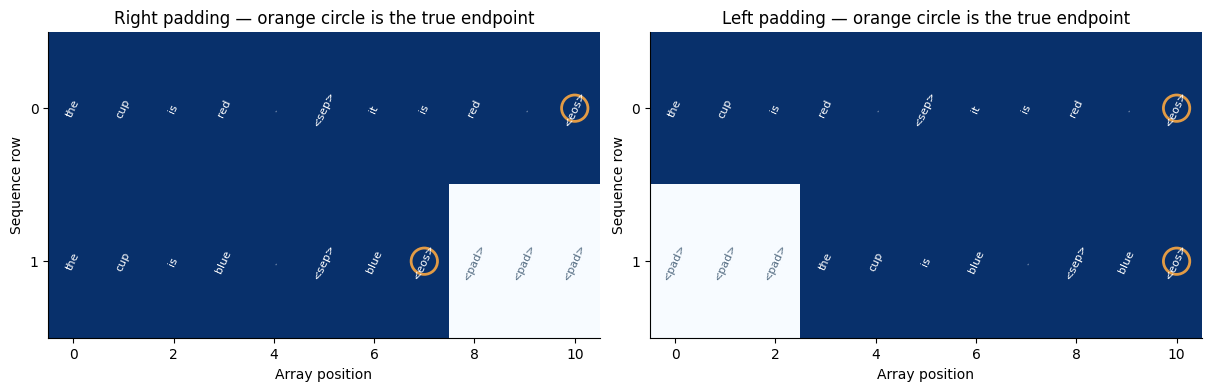

Score difference: [0.0, 0.0]
Left-padding true indices: [10, 10]
Incorrect length-minus-one indices: [10, 7]


In [4]:
texts = [('the cup is red .', 'It is red .'), ('the cup is blue .', 'blue')]
right = text_batch(vocab, texts, padding='right')
left = text_batch(vocab, texts, padding='left')
with torch.no_grad():
    scores_right = initial(right['ids'], right['mask'])
    scores_left = initial(left['ids'], left['mask'])
torch.testing.assert_close(scores_right, scores_left, atol=1e-12, rtol=1e-12)
assert torch.isfinite(initial.hidden(left['ids'], left['mask'])).all()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
for ax, batch, title in zip(axes, [right, left], ['Right padding', 'Left padding']):
    ax.imshow(batch['mask'].numpy(), vmin=0, vmax=1, cmap='Blues', aspect='auto')
    for row in range(len(texts)):
        for col in range(batch['ids'].shape[1]):
            token = vocab.tokens[int(batch['ids'][row, col])]
            ax.text(col, row, token, rotation=65, fontsize=8, ha='center', va='center',
                    color='white' if batch['mask'][row, col] else '#526a80')
        ax.scatter(int(batch['endpoints'][row]), row, s=360, facecolors='none',
                   edgecolors='#e29b45', linewidths=2)
    ax.set_title(title + ' — orange circle is the true endpoint')
    ax.set_xlabel('Array position'); ax.set_ylabel('Sequence row'); ax.set_yticks([0, 1])
plt.show()
print('Score difference:', (scores_left - scores_right).tolist())
print('Left-padding true indices:', left['endpoints'].tolist())
print('Incorrect length-minus-one indices:', (left['mask'].sum(1) - 1).tolist())

![Saved valid-mask grids comparing left and right padding with final EOS positions](../figures/chapter-10/day-16-03_text_reward_and_process_labels-02.png)

EOS remains the final valid token in each row, even when its array index changes. All-padding rows are rejected. Padded queries can have no legal attention keys, so the implementation uses a finite mask sentinel and zeros their outputs; it does not apply softmax to an all-negative-infinity row. The EOS policy is part of the exported interface, not an off-by-one repair after training.

## 3 Let the text representation learn

Predict: if both pair branches share the encoder, will the head alone receive gradients? Run the adjacent complete reference and inspect the first backward pass. Then explain why training loss alone cannot establish robustness to a new answer format.

First preference backward: {'embedding_norm': 8.896741672999474e-05, 'attention_qkv_norm': 0.0006646888444424303, 'head_norm': 0.00043451769564595836}


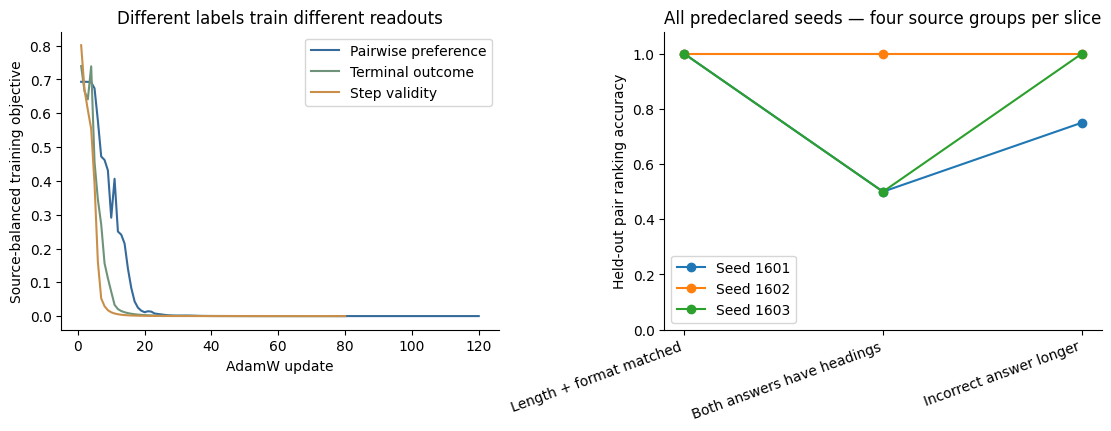

In [5]:
preference, preference_fit = fit_text_model(fixture, vocab, seed=1601, objective='preference')
outcome, outcome_fit = fit_text_model(fixture, vocab, seed=1601, objective='outcome')
process, process_fit = fit_text_model(fixture, vocab, seed=1601, objective='process')
print('First preference backward:', preference_fit['first_backward'])
assert all(value > 0 for value in preference_fit['first_backward'].values())
cal_rows = [r for r in fixture['pairs'] if r['split'] == 'calibration']
test_rows = nuisance_pairs([r for r in fixture['pairs'] if r['split'] == 'test'])
current_test = evaluate_pairs(preference, vocab, test_rows)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for fit, label, color in [(preference_fit, 'Pairwise preference', '#356a9a'),
                          (outcome_fit, 'Terminal outcome', '#6f937a'),
                          (process_fit, 'Step validity', '#c98f4a')]:
    axes[0].plot(np.arange(1, len(fit['history']) + 1), fit['history'], label=label, color=color)
axes[0].set(xlabel='AdamW update', ylabel='Source-balanced training objective', title='Different labels train different readouts')
axes[0].legend()
conditions = ['matched-length-format', 'matched-heading', 'longer-incorrect']
for index, seed in enumerate(report['seeds']):
    scores = [seed['test_raw']['slices'][c]['ranking_accuracy'] for c in conditions]
    axes[1].plot(np.arange(3), scores, 'o-', label=f"Seed {seed['seed']}")
axes[1].set_xticks(range(3), ['Length + format matched', 'Both answers have headings', 'Incorrect answer longer'], rotation=20, ha='right')
axes[1].set(ylim=(0, 1.08), ylabel='Held-out pair ranking accuracy', title='All predeclared seeds — four source groups per slice')
axes[1].legend()
plt.show()

![Saved learning curves and measured three-seed held-out ranking under formatting and length changes](../figures/chapter-10/day-16-03_text_reward_and_process_labels-03.png)

The three objectives fit their training labels. Perfect ranking on the narrow matched-format color slice does not make the reward robust: heading/length interventions reveal seed-dependent failures. Every predeclared seed is reported; the frozen policy reward is seed 1601 chosen before testing, not the best-looking seed. This is not a pretrained reward-model benchmark.

## 4 A correct conclusion can follow a false step

Exercise: compare these four authored traces: valid step/correct answer, invalid step/correct answer, valid step/wrong answer and invalid step/wrong answer. Would a single final-answer label tell the process model which equation was valid?

Step targets occur only on `<step>` marker positions. The terminal outcome target occurs at final EOS. Neither is an expected future return; a value critic would have a different target contract.

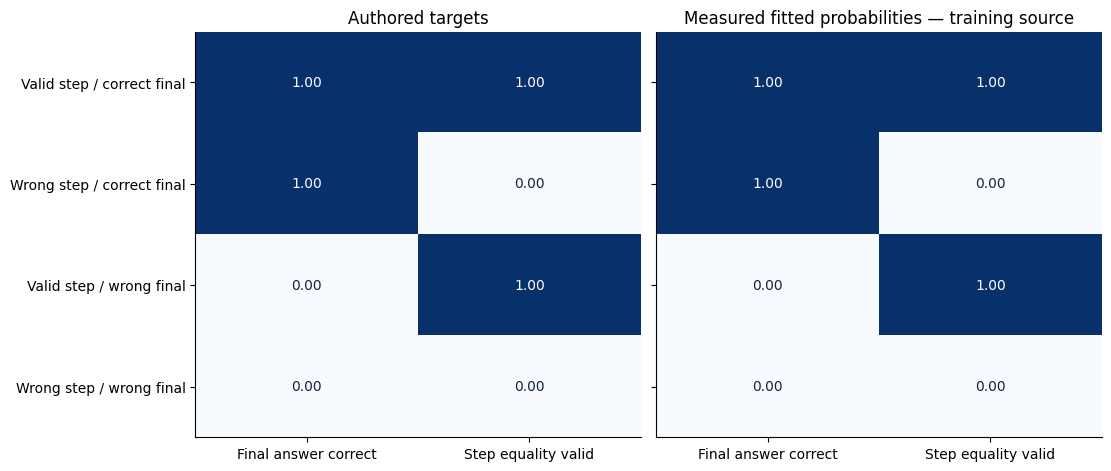

In [6]:
rows = fixture['processes'][:4]
trace_result = evaluate_traces(outcome, process, vocab, rows)
actual_outcome = [r['outcome_probability'] for r in trace_result['predictions']]
actual_step = [r['step_probabilities'][0] for r in trace_result['predictions']]
truth = np.array([[r['outcome'], int(r['steps'][0]['valid'])] for r in rows])
predictions = np.array([actual_outcome, actual_step]).T
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
case_names = ['Valid step / correct final', 'Wrong step / correct final',
              'Valid step / wrong final', 'Wrong step / wrong final']
for ax, values, title in zip(axes, [truth, predictions], ['Authored targets', 'Measured fitted probabilities — training source']):
    ax.imshow(values, vmin=0, vmax=1, cmap='Blues', aspect='auto')
    ax.set_xticks([0, 1], ['Final answer correct', 'Step equality valid'])
    ax.set_yticks(range(4), case_names if ax is axes[0] else [])
    ax.set_title(title)
    for row in range(4):
        for col in range(2):
            ax.text(col, row, f'{values[row,col]:.2f}', ha='center', va='center',
                    color='white' if values[row,col] > .65 else '#142538')
plt.show()
batch = process_batch(vocab, rows, padding='left')
supervised = batch['step_targets'] != -100
assert (batch['ids'][supervised] == 3).all()
assert (batch['step_targets'].gather(1, batch['endpoints'][:, None]) == -100).all()

![Saved authored terminal-versus-step targets and their independently fitted probabilities on the training source](../figures/chapter-10/day-16-03_text_reward_and_process_labels-04.png)

The off-diagonal cases matter: final correctness does not validate a false equality, and a valid local equality does not establish a correct final answer. The plot explicitly shows a training source, not held-out generalization. Changing the final answer must not influence the earlier step representation in the same causal forward pass.

In [7]:
original = rows[0]
changed = {**original, 'final': 'Final : 6 .'}
batch = process_batch(vocab, [original, changed])
with torch.no_grad():
    scores = process.token_scores(batch['ids'], batch['mask'])
positions = (batch['step_targets'][0] != -100).nonzero().flatten()
torch.testing.assert_close(scores[0, positions], scores[1, positions], atol=1e-12, rtol=1e-12)
print('Earlier step-score difference after changing final text:',
      (scores[0, positions] - scores[1, positions]).tolist())
# Held-out arithmetic labels contain a deliberately visible representation limit.
heldout = [r for r in fixture['processes'] if r['split'] == 'test']
held_batch = process_batch(vocab, heldout)
print('Held-out unknown tokens:', held_batch['unknown_tokens'])
assert torch.equal(held_batch['ids'][0], held_batch['ids'][1])
assert heldout[0]['steps'][0]['valid'] != heldout[1]['steps'][0]['valid']
print('Opposite step labels can have identical token IDs: general arithmetic is not established.')
# Raw source separation does not guarantee encoded-input separation.
def pair_encoding(row):
    pair = text_batch(vocab, [(row['prompt'], row['left']), (row['prompt'], row['right'])])
    return tuple(tuple(pair['ids'][i, pair['mask'][i]].tolist()) for i in range(2))
calibration_encodings = {pair_encoding(row) for row in cal_rows}
baseline_test = [r for r in fixture['pairs'] if r['split'] == 'test']
encoded_collisions = [r['pair_id'] for r in baseline_test if pair_encoding(r) in calibration_encodings]
assert len(encoded_collisions) == 4
print('Calibration/test encoded collisions:', len(encoded_collisions), '/', len(baseline_test))


Earlier step-score difference after changing final text: [0.0]
Held-out unknown tokens: [['7', '7'], ['8', '7'], ['7', '8'], ['8', '8']]
Opposite step labels can have identical token IDs: general arithmetic is not established.
Calibration/test encoded collisions: 4 / 4


Numbers 7 and 8 were absent from the fitted training vocabulary and both map to the declared unknown token. Opposite held-out arithmetic labels can therefore have identical encodings. All three seeds reach only 0.5 held-out outcome/step accuracy here, with overconfident losses preserved in the report. This is a representation/evidence failure, not proof that the optimizer failed or that the model learned arithmetic. An improved numeric tokenizer would be a new declared intervention, not a quiet repair of these results.

The color experiment has a second encoding boundary: unseen “box” and “book” both become `<unk>`. All four baseline test pairs duplicate calibration encodings despite disjoint raw source groups. Temperature selection uses only calibration labels, but this result cannot establish independent held-out calibration generalization. The original artifacts remain intact; a vocabulary intervention requires a new protocol.

## 5 Same substance does not guarantee the same reward

Exercise: take the exact correct answer, then add a heading or redundant sentence. Under a factual-answer rubric both are equally acceptable, so the declared binary approximation has target 0.5. Will the learned reward margin necessarily be zero?

The adjacent reference visualizes every source rather than hiding failures behind an average. A half target is a binary approximation to a tie, not an independent three-outcome tie model.

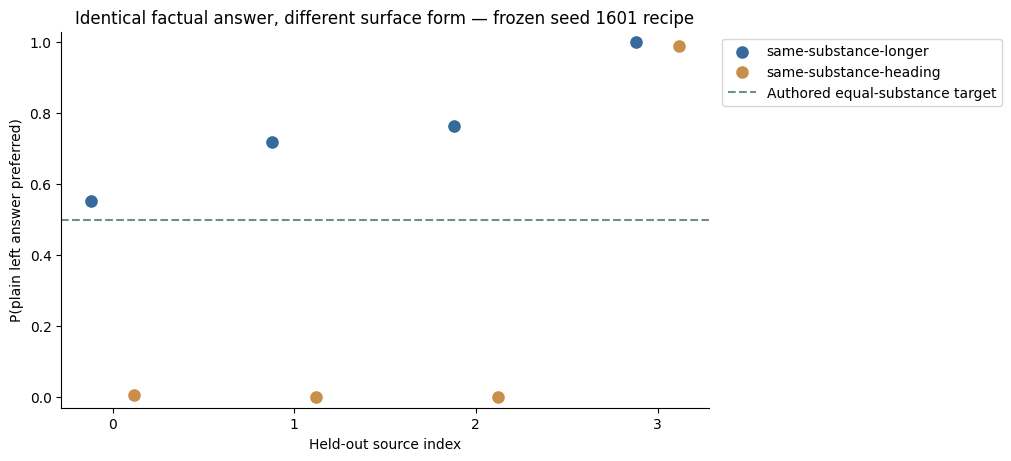

{'same-substance-heading': 0.4959085405835447, 'same-substance-longer': 0.34249668716637327}


In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
for condition, offset, color in [('same-substance-longer', -.12, '#356a9a'),
                                  ('same-substance-heading', .12, '#c98f4a')]:
    selected = [r for r in current_test['predictions'] if r['condition'] == condition]
    ax.scatter(np.arange(len(selected)) + offset, [r['p_left'] for r in selected], label=condition, s=65, color=color)
ax.axhline(.5, color='#6f937a', linestyle='--', label='Authored equal-substance target')
ax.set(xlabel='Held-out source index', ylabel='P(plain left answer preferred)', ylim=(-.03, 1.03),
       title='Identical factual answer, different surface form — frozen seed 1601 recipe')
ax.set_xticks(range(4))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()
print({condition: metrics['brier'] for condition, metrics in current_test['slices'].items()
       if condition.startswith('same-substance')})

![Saved measured preference probabilities for equal-factual-content length and heading variants](../figures/chapter-10/day-16-03_text_reward_and_process_labels-05.png)

A score can change under a nuisance even when the underlying factual content does not. Soft-target Brier here is the expected Bernoulli score under the declared target; it retains the 0.25 irreducible floor at probability 0.5. This is not an observed human preference calibration claim.

## 6 Freeze identity as well as parameters

Before running the complete reference, explain why storing tensor shapes alone cannot prevent a same-size vocabulary permutation. Which EOS, unknown-token and endpoint rules must travel with the scalar head?

In [9]:
frozen_path = ROOT / 'fixtures/text-reward/frozen-preference-seed1601.json'
frozen = load_frozen(frozen_path, expected_interface=vocab.interface(include_eos=True))
texts = [(r['prompt'], r['left']) for r in cal_rows]
batch = text_batch(vocab, texts)
with torch.no_grad():
    current_scores = preference(batch['ids'], batch['mask'])
# Serialization equality compares the same saved state in this environment.
# Retraining on another Torch version is a separate reproducibility question.
loaded_again = load_frozen(frozen_path, expected_interface=vocab.interface(include_eos=True))
assert torch.equal(frozen.score_many(texts), loaded_again.score_many(texts))
word_retraining_delta = float((current_scores - frozen.score_many(texts)).abs().max())
print('Measured fresh-vs-historical word retraining score delta:', word_retraining_delta)
print('Exact equality after reloading the same saved word state:', True)
assert not any(p.requires_grad for p in frozen.model.parameters())
assert not frozen.score_many(texts).requires_grad
print('Frozen seed:', frozen.identity['seed'])
print('Endpoint:', frozen.identity['endpoint_semantics'])
print('File hash:', frozen.identity['file_sha256'])
print('Example score:', frozen.score(texts[0][0], texts[0][1]))
# Temperature selection used calibration labels only; it never selected this checkpoint.
print('Recorded calibration-only temperatures:',
      [(s['seed'], s['temperature_selection']['selected']) for s in report['seeds']])

Measured fresh-vs-historical word retraining score delta: 2.0122570276726037e-11
Exact equality after reloading the same saved word state: True
Frozen seed: 1601
Endpoint: final nonpadding EOS
File hash: 3e631f45c28ef7af2dae4280a9e3e6cf3bcc7bf76e3ecbd8307ae6ce9e6c8d4d
Example score: -9.54138669126626
Recorded calibration-only temperatures: [(1601, 0.5), (1602, 0.5), (1603, 0.5)]


The JSON-only export stores every numeric weight, the model config, ordered token meanings, encoding rules, special IDs, source/fixture identity and endpoint policy. Loading validates hashes, state shapes and the caller's expected interface, then disables reward gradients. A self-hash detects inconsistent edits, not a malicious actor recomputing every hash; an external expected interface/file identity is the trust boundary.

The later policy experiment may optimize this frozen score, but it must still measure factual outcomes independently. A reward that ranks the ordinary pairs correctly can be exploited by optimized formatting. Preserve the earlier known-feature shortcut lesson: it isolates a different mechanism.

[Measured report](../../experiments/reports/2026-10-04-text-reward.md) · [fixture](../../fixtures/text-reward/README.md) · [solutions](../../book/solutions/10-preferences-and-reward-models.md)

Prepared notebooks and CPU checks do not establish learner mastery, live human agreement, pretrained reward quality or a Spark model-scale experiment.

Exact serialization compares the same saved weights in one environment. Fresh retraining under the newer locked Torch version can differ from the historical Spark training run; its measured score delta is printed rather than silently treated as exact. The historical file and report stay unchanged. The first clean-kernel attempt that exposed this distinction is retained in the character verification report.

## 7 Preserve a distinction before asking the model to learn it

The word-token run above remains historical evidence, including its four calibration/test input collisions and arithmetic unknown-token failures. A separately specified character arm uses a fixed printable ASCII alphabet, not a vocabulary fitted to held-out texts. It rejects unsupported characters before casefolding, preserves spaces/punctuation and includes SEP/STEP/EOS. Its position bound is fixed at 160 before any fitting.

Prediction: will giving “box” and “book” distinct encodings automatically produce correct held-out reward scores? First inspect exact-input independence; then inspect the unchanged neural training recipe. This is not an equal-compute tokenizer comparison: the sequences and position table differ.


Whole pair/swap/source/response/STEP-prefix gates: True
Largest pair/trace lengths: 111 56
Distinct character IDs: {'7': [28], '8': [29]}


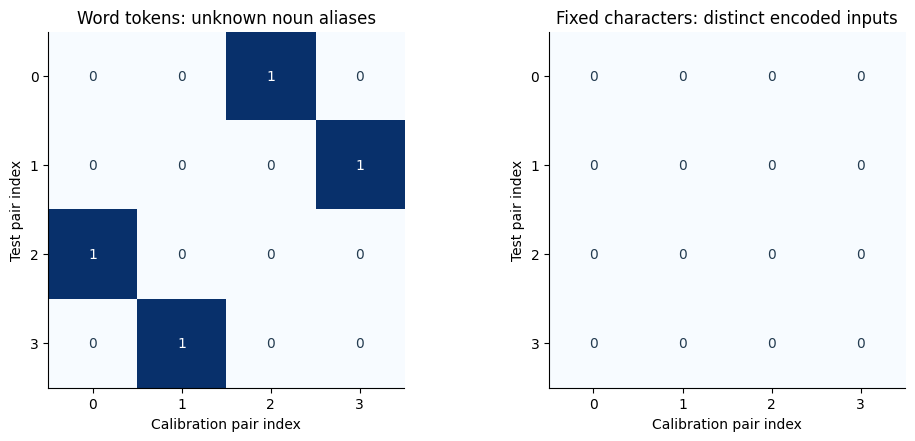

In [10]:
from dongxi_llms.char_reward_lab import (
    ASCIICharacterVocabulary, char_config, char_text_batch, char_process_batch,
    encoding_audit, fit_char_model, load_char_reward,
)
cvocab = ASCIICharacterVocabulary()
char_report = json.loads((ROOT / 'experiments/reports/2026-10-04-text-reward-character.json').read_text())
char_audit = encoding_audit(fixture, cvocab)
assert char_audit['passed'] and not char_audit['issues']
print('Whole pair/swap/source/response/STEP-prefix gates:', char_audit['passed'])
print('Largest pair/trace lengths:', char_audit['maximum_pair_positions'], char_audit['maximum_trace_positions'])
print('Distinct character IDs:', {c: cvocab.encode(c)[0] for c in ['7', '8']})
assert cvocab.encode('box')[0] != cvocab.encode('book')[0]
cal_base = [r for r in fixture['pairs'] if r['split'] == 'calibration']
test_base = [r for r in fixture['pairs'] if r['split'] == 'test']
def unordered_encoding(vocabulary, row):
    pair = text_batch(vocabulary, [(row['prompt'], row['left']), (row['prompt'], row['right'])], max_positions=160)
    sequences = [tuple(pair['ids'][i, pair['mask'][i]].tolist()) for i in range(2)]
    return tuple(sorted(sequences))
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3), constrained_layout=True)
for ax, vocabulary, title in zip(axes, [vocab, cvocab], ['Word tokens: unknown noun aliases', 'Fixed characters: distinct encoded inputs']):
    collision = np.array([[unordered_encoding(vocabulary, a) == unordered_encoding(vocabulary, b)
                           for b in cal_base] for a in test_base], dtype=int)
    ax.imshow(collision, cmap='Blues', vmin=0, vmax=1)
    ax.set(xlabel='Calibration pair index', ylabel='Test pair index', title=title)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    for i in range(4):
        for j in range(4):
            ax.text(j, i, str(collision[i,j]), ha='center', va='center',
                    color='white' if collision[i,j] else '#233b50')
    if vocabulary is cvocab:
        assert not collision.any()
plt.show()


![Saved exact encoded-pair collisions contrasting historical word tokens and the fixed character arm](../figures/chapter-10/day-16-03_text_reward_and_process_labels-06.png)

A 1 means an exact whole-pair match, including swapped candidate order; 0 means distinct inputs. The character gate also checks full prompts, prompt/completion inputs and complete causal prefixes through supervised STEP markers. Arbitrary shared prefixes such as the first character “C” are not leakage. Related repeated equal-label prefixes within one source stay related, not new independent sources. Exact-input separation does not rule out semantic similarity or establish reward quality.


## 8 The missing information was necessary, not sufficient

Exercise: explain why the character model can fit its training comparisons while still assigning a confidently wrong preference on a different object. Run the predeclared seed 1611 reference; do not add updates after inspecting the test results. All three experiment seeds are shown, including failures.


Character backbone/head first backward: {'embedding_norm': 0.035716383191722524, 'attention_qkv_norm': 0.048331832960346016, 'head_norm': 0.9317636943539941}


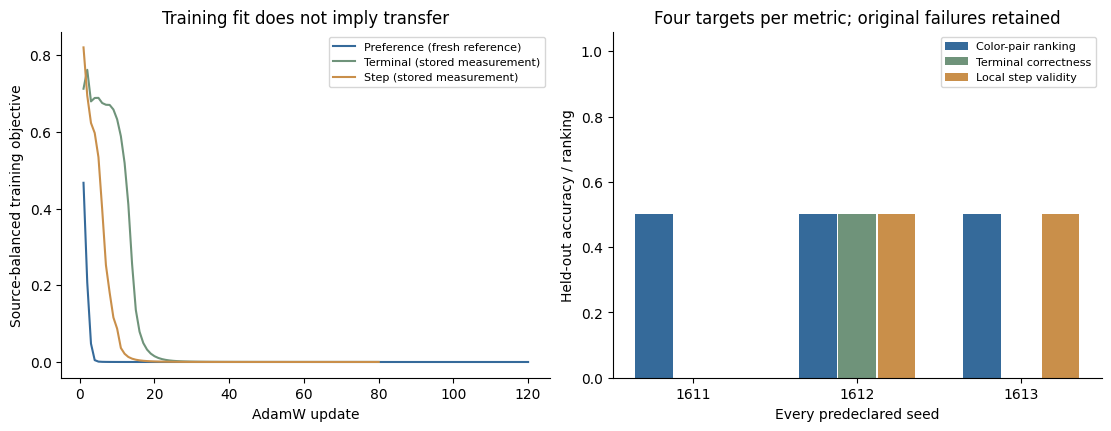

In [11]:
char_live, char_fit = fit_char_model(fixture, cvocab, seed=1611)
print('Character backbone/head first backward:', char_fit['first_backward'])
assert all(value > 0 for value in char_fit['first_backward'].values())
first_char = char_report['seeds'][0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for fit, label, color in [(char_fit, 'Preference (fresh reference)', '#356a9a'),
                          (first_char['outcome_fit'], 'Terminal (stored measurement)', '#6f937a'),
                          (first_char['process_fit'], 'Step (stored measurement)', '#c98f4a')]:
    axes[0].plot(np.arange(1, len(fit['history']) + 1), fit['history'], label=label, color=color)
axes[0].set(xlabel='AdamW update', ylabel='Source-balanced training objective', title='Training fit does not imply transfer')
axes[0].legend(fontsize=8)
positions = np.arange(3)
for offset, field, label, color in [(-.24, 'preference', 'Color-pair ranking', '#356a9a'),
                                   (0., 'outcome', 'Terminal correctness', '#6f937a'),
                                   (.24, 'process', 'Local step validity', '#c98f4a')]:
    values = [s['test_raw']['slices']['matched-length-format']['ranking_accuracy'] if field == 'preference'
              else s['traces']['test'][field + '_metrics']['ranking_accuracy'] for s in char_report['seeds']]
    axes[1].bar(positions + offset, values, width=.23, label=label, color=color)
axes[1].set_xticks(positions, [str(s['seed']) for s in char_report['seeds']])
axes[1].set(xlabel='Every predeclared seed', ylabel='Held-out accuracy / ranking', ylim=(0, 1.06),
            title='Four targets per metric; original failures retained')
axes[1].legend(fontsize=8)
plt.show()


![Saved character-arm learning curves and every predeclared seed's independent held-out preference, terminal and process metrics](../figures/chapter-10/day-16-03_text_reward_and_process_labels-07.png)

All three objectives fit their training labels. Ordinary held-out color ranking is 0.5 for each seed; terminal accuracy is 0, 0.5, 0 and step accuracy is 0, 0.5, 0.5. The character model no longer loses the number distinction, so an unknown-ID collision cannot explain these new failures. Preserved information is necessary but not sufficient for a learned rule. These results do not justify more steps, a new seed or a quieter replacement of difficult tests under the frozen protocol.


## 9 Calibrate probabilities without changing the selected checkpoint

Prediction: can a higher temperature correct a wrong ranking? The grid 0.5, 1, 2, 4 was frozen in advance; all seeds choose 4 using calibration NLL only. The following reference uses the retained independent test bins and intervention losses, not test-selected temperatures. Each slice has only four sources, so treat a smooth-looking line as a small counted observation.


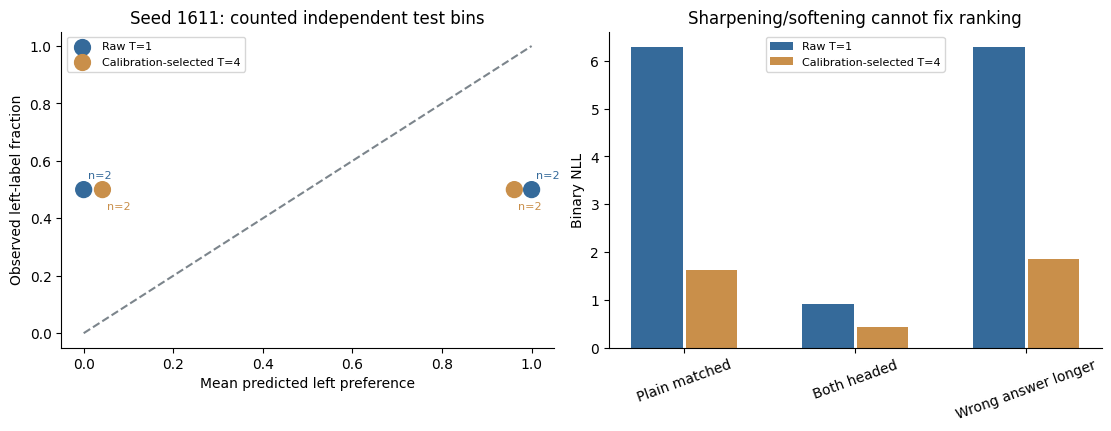

Calibration-only selections: [(1611, 4.0), (1612, 4.0), (1613, 4.0)]


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for field, label, color in [('test_raw', 'Raw T=1', '#356a9a'), ('test_calibrated', 'Calibration-selected T=4', '#c98f4a')]:
    bins = first_char[field]['slices']['matched-length-format']['reliability']
    axes[0].scatter([b['predicted'] for b in bins], [b['observed'] for b in bins],
                    s=[65 * b['count'] for b in bins], color=color, label=label)
    for b in bins:
        axes[0].annotate('n=' + str(b['count']), (b['predicted'], b['observed']), xytext=(3, 8 if field == 'test_raw' else -14), textcoords='offset points', fontsize=8, color=color)
axes[0].plot([0, 1], [0, 1], '--', color='#7c858c')
axes[0].set(xlabel='Mean predicted left preference', ylabel='Observed left-label fraction',
            xlim=(-.05, 1.05), ylim=(-.05, 1.05), title='Seed 1611: counted independent test bins')
axes[0].legend(fontsize=8)
conditions = ['matched-length-format', 'matched-heading', 'longer-incorrect']
x = np.arange(len(conditions))
for shift, field, label, color in [(-.16, 'test_raw', 'Raw T=1', '#356a9a'), (.16, 'test_calibrated', 'Calibration-selected T=4', '#c98f4a')]:
    axes[1].bar(x + shift, [first_char[field]['slices'][c]['nll'] for c in conditions], width=.3, label=label, color=color)
axes[1].set_xticks(x, ['Plain matched', 'Both headed', 'Wrong answer longer'], rotation=20)
axes[1].set(ylabel='Binary NLL', title='Sharpening/softening cannot fix ranking')
axes[1].legend(fontsize=8)
plt.show()
print('Calibration-only selections:', [(s['seed'], s['temperature_selection']['selected']) for s in char_report['seeds']])


![Saved counted test reliability bins and raw versus calibration-selected NLL under formatting and length changes](../figures/chapter-10/day-16-03_text_reward_and_process_labels-08.png)

Temperature softens overconfidence here but preserves the score ordering. It cannot turn a learned wrong comparison into a correct one. The labels are authored binary factual comparisons, not human preference frequencies. Equal-substance heading/length pairs remain in the report with declared soft-target Brier conventions and their irreducible 0.25 floor.


## 10 Freeze the new interface without rewriting the old evidence

Exercise: why must the new reward have its own file/interface identity even though its decoder width and head shape match the word model? Change a future final answer and inspect the earlier marker scores. Then try an unsupported character and observe explicit rejection rather than an unknown ID.


In [13]:
char_path = ROOT / 'fixtures/text-reward/frozen-char-preference-seed1611.json'
char_frozen = load_char_reward(char_path, expected_interface=cvocab.interface(),
                              expected_file_sha256=first_char['frozen_export']['file_sha256'])
texts_char = [(r['prompt'], r['left']) for r in cal_base]
b = char_text_batch(cvocab, texts_char)
with torch.no_grad():
    assert torch.equal(char_live(b['ids'], b['mask']), char_frozen.score_many(texts_char))
assert not char_frozen.score_many(texts_char).requires_grad
assert not any(p.requires_grad for p in char_frozen.model.parameters())
trace = fixture['processes'][0]
future_change = {**trace, 'final': 'Final : 12345 .'}
cb = char_process_batch(cvocab, [trace, future_change])
positions = (cb['step_targets'][0] != -100).nonzero().flatten()
with torch.no_grad():
    marker_scores = char_frozen.model.token_scores(cb['ids'], cb['mask'])
torch.testing.assert_close(marker_scores[0, positions], marker_scores[1, positions], atol=1e-12, rtol=1e-12)
print('Exact fresh/save/reload scores:', True, '| fixed seed:', char_frozen.identity['seed'])
print('Frozen raw score is not a goodness probability:', char_frozen.score(texts_char[0][0], texts_char[0][1]))
try:
    char_frozen.score('What is the color ?', '数')
except ValueError as error:
    print('Unsupported-character failure retained:', str(error))
else:
    raise AssertionError('Unsupported input was silently accepted')


Exact fresh/save/reload scores: True | fixed seed: 1611
Frozen raw score is not a goodness probability: 6.280513577735143
Unsupported-character failure retained: Unsupported character: only printable ASCII is accepted before casefolding


The preselected character export is complete numeric JSON with its own protocol, source, input, encoding, vocabulary and endpoint hashes. Scores are detached and reward weights stay frozen. This scalar is an imperfect proxy even on ordinary independent inputs; a later policy optimization must report factual quality separately.

[Character specification](../../experiments/specs/2026-10-04-text-reward-vocabulary-intervention.md) · [new measured report](../../experiments/reports/2026-10-04-text-reward-character.md) · [unchanged word report](../../experiments/reports/2026-10-04-text-reward.md)

Exact-input disjointness and completed CPU measurements close a narrow evidence gap, not robust reward learning, pretrained validation, general arithmetic or learner mastery.
